https://en.wikipedia.org/wiki/Pan%E2%80%93Tompkins_algorithm#cite_note-PanTompkins-1
QRS image (순서대로 P  QRS  T)
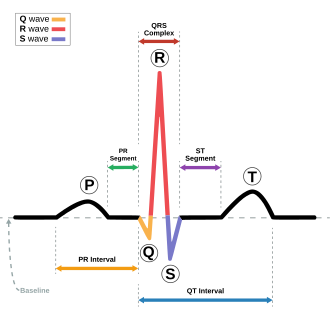

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

### 기존 trial dataset은 noise가 너무 심해서, input data를 추출하는 과정은 사수(정한빈 박사과정)님께서 주신 ECG_ex.csv file을 사용.
- 기존 파일과 다르게 header가 없어서, header 추가. (기존 코드를 사용하기 위함)

In [2]:
def add_header_with_pandas(input_file, new_dir):
    # 원본 파일 경로에서 디렉토리와 파일명 추출
    dir_name, base_name = os.path.split(input_file)
    file_name, ext = os.path.splitext(base_name)  # 확장자 분리 (.csv)

    # 새로운 디렉토리로 새 파일 이름 생성 (예: ECG_ex_with_header.csv)
    output_file = os.path.join(new_dir, f"{file_name}_with_header{ext}")

    # CSV 파일을 읽고, 헤더 추가 후 저장
    df = pd.read_csv(input_file, header=None)
    df.to_csv(output_file, index=False, header=['Time', 'EcgWaveform'])

    return output_file  # 새로 생성된 파일 경로 반환

# 실행 코드
if __name__ == '__main__':
    input_csv = "/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Raw_Time_ECG_dataset/ECG_ex.csv"
    new_dir = "/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Header_Time_ECG_dataset"  # 원하는 새로운 디렉토리 경로
    new_csv = add_header_with_pandas(input_csv, new_dir)  # 자동으로 새로운 파일명 생성
    print(f"Header included new csv file path: {new_csv}")


Header included new csv file path: /home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Header_Time_ECG_dataset/ECG_ex_with_header.csv


Loading all csv files into dataframe

- data_frames structure
    - file1 name : df1_info,
    - file2 name : df2_info,
    ...

- df_info structure
    - "data_frame" : df,
    - "diabetes" : 1 (diabetes) or -1 (healthy) or 0 (Unknown),

    - "filtered_threshold" : filtered_threshold,
    - "R_peaks" : R_peaks,
    - "filtered_R_peaks" : filtered_R_peaks,
    - "RR_intervals" : RR_intervals,

    - "FFT_HRV_analysis" : FFT_HRV_analysis

- df structure
    - 'Time' : ~,
    - 'EcgWaveform' : ~,
    - 'filtered_ECG' : ~

In [3]:
def load_csv_files(root_folder, diabetes):

    # 1. Search all csv files & collect them
    csv_files = [] # csv file path list

    for root, _, files in os.walk(root_folder):  # root_folder & subfolders search
        for file in files:
            if file.endswith('.csv'):  # choose only csv files
                csv_files.append(os.path.join(root, file))
    
    # 2. CSV file loading & pre-processing
    data_frames = dict()  # key: file_name, value: df_info (e.g. file1 : df1_info, ...)
    '''
    df_info = dictionary w/ data_frame information
    # "data_frame" : df = {'Time': ~, 'EcgWaveform' : ~, ...}
    # "diabetes": 1 or 0
    # "R_peaks" : R_peaks,
    # "RR_intervals" : RR_intervals,
    # "FFT_HRV_analysis" : FFT_HRV_analysis
    '''

    for file_path in csv_files:
        try:
            # read each csv file into a data_frame(df)
            df = pd.read_csv(file_path)
            
            # Column check & data validation
            if 'Time' in df.columns and 'EcgWaveform' in df.columns:
                # Convert to datatime object for operation in python. (if fail, convert to NaT)
                # df['Time'] = pd.to_datetime(df['Time'], errors='coerce') # 일/월/연 단위로 처리리
                df['Time'] = pd.to_numeric(df['Time'], errors='coerce')  # 초 단위로 처리

                # Convert to numeric object for operation in python. (if fail, convert to NaN)
                df['EcgWaveform'] = pd.to_numeric(df['EcgWaveform'], errors='coerce')
                
                # Remove invalid data(NaT, NaN rows) in data_frame
                df = df.dropna(subset=['Time', 'EcgWaveform'])
                
                # Elimination 이후 data가 너무 적게 남지 않았는지 확인.
                if len(df) < 10:
                    print(f"Warning: {file_path} has insufficient valid data ({len(df)} rows).")

                # Store each file_name : data_frame(df) into the data_frames dictionary
                file_name = os.path.basename(file_path) # extract file_name from file_path
                data_frames[file_name] = dict()
                data_frames[file_name]["data_frame"] = df
                
                # labeling
                if diabetes == "diabetes":
                    data_frames[file_name]["diabetes"] = -1
                elif diabetes == "healthy":
                    data_frames[file_name]["healthy"] = 1
                else:
                    data_frames[file_name]["Unknown"] = 0

            else:
                print(f"'{file_path}' file does Not have valid Time, EcgWaveform column.")
        
        except Exception as e:
            print(f"An error occurred while loading the file '{file_path}': {e}")
    
    return data_frames

In [4]:
# load dataframes
diabetes_root_folder = " "
healthy_root_folder = " "
Unknown_root_folder = "/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Header_Time_ECG_dataset"

# diabetes_data_frames = load_csv_files(diabetes_root_folder, "diabetes")
# healthy_data_frames = load_csv_files(healthy_root_folder, "healthy")
Unknown_data_frames = load_csv_files(Unknown_root_folder, "Unknown")

# integrated data_frames
# data_frames = diabetes_data_frames | healthy_data_frames
data_frames = Unknown_data_frames

### Sampling Frequency 구하기


In [5]:
def calculate_sampling_frequency(df):
    """ 데이터프레임에서 샘플링 주파수(Fs)를 계산 """
    # Time 열이 datetime 형식인지 확인하고 변환
    if not pd.api.types.is_datetime64_any_dtype(df['Time']):
        df['Time'] = pd.to_numeric(df['Time'], errors='coerce')

    # 시간 차이(Δt) 계산
    time_diff = df['Time'].diff().dropna()  # 첫 번째 값은 NaN이므로 제거

    # 평균 샘플링 간격(Δt 평균)의 역수로 Fs 계산
    fs = 1 / time_diff.mean()
    
    return fs

# CSV 파일 로드 후 샘플링 주파수 계산
file_path = "/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Header_Time_ECG_dataset/ECG_ex_with_header.csv"
df_ = pd.read_csv(file_path)

fs = calculate_sampling_frequency(df_)
print(f"Sampling Frequency(fs): {fs:.2f} Hz")

Sampling Frequency(fs): 200.00 Hz


### Raw data 가시화

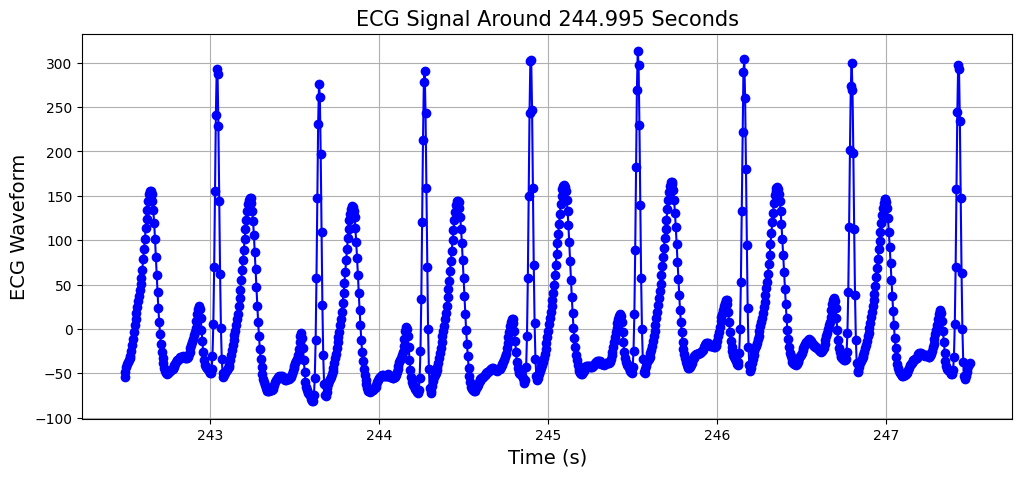

In [8]:
def plot_around_standard_time(df, standard_time=None, N=5):
    """
    standard_time을 중심으로 N초 간의 데이터를 사용하여 ECG 그래프를 그린다.

    Parameters:
    df (pd.DataFrame): Time, EcgWaveform 데이터가 있는 pandas DataFrame
    standard_time (float, optional): 기준이 될 시간 (초). 기본값은 데이터의 중앙값
    N (float, optional): 기준시간을 중심으로 앞뒤 N초 간격. 기본값은 1초
    """
    # standard_time이 None이면 중앙값을 사용
    if standard_time is None:
        standard_time = df['Time'].median()
    
    # standard_time을 중심으로 N초 간격의 데이터 필터링
    start_time = standard_time - N / 2
    end_time = standard_time + N / 2
    
    # standard_time 범위에 해당하는 데이터 선택
    df_filtered = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

    # 그래프 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(df_filtered['Time'], df_filtered['EcgWaveform'], marker='o', linestyle='-', color='b')
    
    # 그래프 꾸미기
    plt.xlabel('Time (s)', fontsize = 14)
    plt.ylabel('ECG Waveform',  fontsize = 14)
    plt.title(f"ECG Signal Around {standard_time} Seconds", fontsize = 15)
    plt.grid(True)
    
    # 그래프 출력
    plt.show()

plot_around_standard_time(df_, N=5)

Pan-Tompkins Algorithm for QRS detection: R_peaks detection

https://en.wikipedia.org/wiki/Pan%E2%80%93Tompkins_algorithm

"""
A real-time QRS detection algorithm
J Pan, W J Tompkins
PMID: 3997178 DOI: 10.1109/TBME.1985.325532
"""

peak: local maxima
- 수정: derivative에서 극대극소 중 극댓값으로 추정하기 위해 부호변화(+ to -)를 추가.

Summary
- (1) 도함수의 부호변화 + > -. 후보 1
- (2) 도함수의 크기 일정값보다 큼. 후보 2
- (3) find_peaks 함수. 후보 3
===
> 초기
1. noise가 많은 wearable data의 경우 R_peak이 항상 유사한 값을 가진다는 보장이 없음.
2. 초기에는 ECG_data의 홀수차승 제곱을 통해 R_peak을 어떤 절대적인 값(이동평균의 max * 0.5) 위로 분류하였으나, noise 때문인지 좋은 성능일 가져오지 않았음. each R_peak이 상이한 값을 가지는 경우가 많았기 때문임.
3. 따라서 ECG data의 R_peak을 일정한 값(threshold)을 기준으로 R_peak detection하는 idea는 폐기하였음.
===
> 나중
4. 이후, R_peak의 ECG value는 다를지언정, neighborhood의 derivative가 급격히 변화한다는 공통점에 착안하여 R_peak detection을 시행함. (후보 2) 이 때 "급격한 변화"의 기준을 derivative 3제곱 크기의 이동평균을 사용하였음.
5. 기존 Pan-Tompkins Algorithm에서는 squared_ECG를 통해 이동평균으로서 derivative 크기를 재단하여 극값을 정하였으나, 더 극단적인 변화를 위해 3제곱을 사용함.
6. find_peaks에서 distance의 경우 Noise가 너무 많아서 RR interval의 threshold(distance)에 의거한 분류는 사용하지 아니하였음.
7. find_peaks에서 height의 경우 초기 idea에서 별로 효과가 없었으므로, 제외하였음.

Experimental parameter (hyper parameter)
- bandpass filter: lowcut, highcut, order
- moving average filter: window size
- refine peaks: min_RR_interval, min_localvalue_derivative

In [9]:
def normalized_signal(Raw_signal, min = -100, max = 100):

    Raw_signal = np.array(Raw_signal)
    min_Raw_signal = np.min(Raw_signal)
    max_Raw_signal = np.max(Raw_signal)
    normalized_signal = ( (max - min) / (max_Raw_signal - min_Raw_signal) ) * (Raw_signal - min_Raw_signal) + min

    return normalized_signal


# Butterworth Filter: Extract signal from lowcut to highcut frequency realated to Heart Rate
def bandpass_filter(signal, fs, lowcut = 5, highcut = 15, order=5):
    # QRS frequency 대역에 집중하려는 경우 5-15 (Hz) 사용 [논문 3p Bandpass Filter 3-4 line]
    nyquist = 0.5 * fs  # Nyquist frequency, Aliasing
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band') # filter coefficient

    return filtfilt(b, a, signal)


# R_peaks detection:
def R_peaks_detection(Raw_ECG_signal, fs):

    # 0. Normarization: -100~100, 각 dataset의 범위를 통일.
    normalized_ECG_signal = normalized_signal(Raw_ECG_signal)

    # 1. Bandpass Filter: 심박수 주파수 외 노이즈 제거.
    filtered_ECG = bandpass_filter(normalized_ECG_signal, fs)

    # 2. Derivative Filter: 극대 포인트 찾기.
    derivative = np.diff(filtered_ECG, prepend = filtered_ECG[0])

    sign_changes = np.diff(np.sign(derivative))
    localmax_indices = np.where(sign_changes == -2)[0] # local_maxima의 index array, candidate (1)

    # 3. Moving Average Filter: R_peak neighborhood에서는 변화율의 크기가 큰 것을 이용. (크기 사용)
    norm_cubed_derivative = np.abs(derivative ** 3)
    window_size = int(fs*0.15)
    moving_avg = np.convolve(norm_cubed_derivative, np.ones(window_size) / window_size, mode='same')
    derivative_threshold = np.mean(moving_avg) + np.std(moving_avg) # 평균 + 1표준편차 (극대/극소의 일종의 height 역할.)
    derivative_indices = np.where(moving_avg > derivative_threshold)[0] # candidate (2)'

    # 4. Refine peaks
    general_indices, _ = find_peaks(filtered_ECG) # candidates (3), peak은 자명하나 R-peak인지는 (1) (2)에서 판단.
    peak_indices = list( set(localmax_indices.tolist()) & set(derivative_indices.tolist()) & set(general_indices.tolist()) )
    peak_indices = np.sort(np.array(peak_indices, dtype=int))
    filtered_threshold = np.min( filtered_ECG[peak_indices] ) # R_peaks의 최저값.

    return peak_indices, filtered_threshold


for file_name, df_info in data_frames.items():
    df = df_info["data_frame"]
    Raw_ECG_signal = df['EcgWaveform']
    
    filtered_ECG = bandpass_filter(normalized_signal(Raw_ECG_signal), fs)
    df['filtered_ECG'] = filtered_ECG # df Table에 new column 추가.

    peak_indices, filtered_threshold = R_peaks_detection(Raw_ECG_signal, fs)
    
    # Store R-peak location as tuple (Time, EcgWaveform)
    R_peaks = [ ( df.loc[index, 'Time'], df.loc[index, 'EcgWaveform'] ) for index in peak_indices ]
    filtered_R_peaks = [ ( df.loc[index, 'Time'], df.loc[index, 'filtered_ECG'] ) for index in peak_indices ]

    # Store RR-intervals into a list
    # RR_intervals = [ ( R_peaks[i][0]-R_peaks[i-1][0] ).total_seconds() for i in range(1, len(R_peaks)) ] # 일/월/연 에서 초 단위로로
    RR_intervals = [ ( R_peaks[i][0]-R_peaks[i-1][0] ) for i in range(1, len(R_peaks)) ] # 단위: second.

    # Save R_peaks and RR_intervals to the data_frames dictionary
    df_info['filtered_threshold'] = filtered_threshold
    df_info['R_peaks'] = R_peaks  # List of (Time, EcgWaveform) tuples
    df_info['filtered_R_peaks'] = filtered_R_peaks
    df_info['RR_intervals'] = RR_intervals  # List of RR-intervals (seconds)

Loading all csv files into dataframe

- data_frames structure
    - file1 name : df1_info

- df_info structure
    - "data_frame" : df,
    - "diabetes" : 1 (diabetes) or -1 (healthy) or 0 (Unknown),

    - "filtered_threshold" : filtered_threshold,
    - "R_peaks" : R_peaks,
    - "filtered_R_peaks" : filtered_R_peaks,
    - "RR_intervals" : RR_intervals,

    - "FFT_HRV_analysis" : FFT_HRV_analysis

- df structure
    - 'Time' : ~,
    - 'EcgWaveform' : ~,
    - 'filtered_ECG' : ~

# of Raw ECG data: 18001
Raw ECG data' info.
<bound method DataFrame.info of           Time  EcgWaveform  filtered_ECG
0      199.995    36.909900      0.576258
1      200.000    45.238000     -0.695854
2      200.005    53.926800     -1.794477
3      200.010    64.227800     -2.541869
4      200.015    74.851300     -2.788457
...        ...          ...           ...
17996  289.975   -19.734900      8.455568
17997  289.980   -13.236800      7.453512
17998  289.985    -7.097070      6.314950
17999  289.990    -0.711102      5.323739
18000  289.995     6.575660      4.568683

[18001 rows x 3 columns]>
Ecg_range: -105.633 ~ 324.173
Average_Human_Heart_Rate (HR): 60 - 100 bpm	sampling frequency of dataset: 200.0 Hz
Expected RR_interval of ECG data: 0.6 - 1.0
Expected # of RR_interval of 1st ECG data: 89 - 149
Filtered_threshold: -7.110630615881389
Average RR_interval: 0.6
# of RR_interval: 149
RR_interval: 
[np.float64(0.6599999999999966), np.float64(0.6550000000000011), np.float64(0.6400

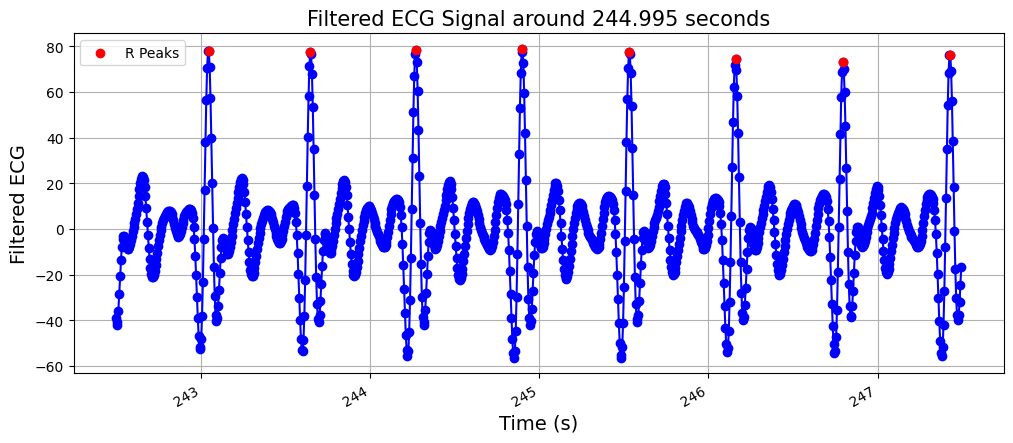

In [10]:
file1_name = list(data_frames.keys())[0]
df1_info = data_frames[file1_name]
df1 = df1_info['data_frame']

print(f"# of Raw ECG data: {len(df1)}")
print(f"Raw ECG data' info.", df1.info, sep = '\n')
print(f"Ecg_range: {min(df1['EcgWaveform'])} ~ {max(df1['EcgWaveform'])}")

print(f"Average_Human_Heart_Rate (HR): 60 - 100 bpm", f"sampling frequency of dataset: {fs} Hz", sep='\t')
print(f"Expected RR_interval of ECG data: {60/100} - {60/60}")
print(f"Expected # of RR_interval of 1st ECG data: { int( len(df1) / (fs * (60/60) ) ) - 1 } - { int( len(df1) / (fs * (60/100) ) ) - 1 }")

print(f"Filtered_threshold: {df1_info['filtered_threshold']}")
print(f"Average RR_interval: {round( sum(df1_info['RR_intervals']) / len(df1_info['RR_intervals']), 2 )}")
print(f"# of RR_interval: {len(df1_info['RR_intervals'])}")
print(f"RR_interval: \n{df1_info['RR_intervals']}")


def filtered_ECG_around_standard_time(df, standard_time=None, N=5):
    df = df_info['data_frame']
    Time = df['Time']
    filtered_threshold = df_info['filtered_threshold']
    filtered_R_peaks = df_info['filtered_R_peaks']

    if standard_time is None:
        standard_time = df['Time'].median()
    
    # standard_time을 중심으로 N초 간격의 데이터 필터링
    start_time = standard_time - N / 2
    end_time = standard_time + N / 2
    
    # standard_time 범위에 해당하는 데이터 선택
    df_filtered = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

    # standard_time 범위에 해당하는 R_peak 선택
    R_peaks_filtered = [(t, v) for t, v in filtered_R_peaks if start_time <= t <= end_time]
    R_peak_times = [t for t, _ in R_peaks_filtered]
    R_peak_values = [v for _, v in R_peaks_filtered]

    # 그래프 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(df_filtered['Time'], df_filtered['filtered_ECG'], marker='o', linestyle='-', color='b')

    # R_peak 위치에 빨간 점 찍기
    # R_peak_times = [R_peak[0] for R_peak in R_peaks]  # R_peak의 시간 추출
    # R_peak_values = [R_peak[1] for R_peak in R_peaks]  # R_peak의 ECG 값 추출
    # plt.scatter(R_peak_times, R_peak_values, color='red', label='R Peaks', zorder=5)
    
    # R_peak 위치에 빨간 점 찍기
    plt.scatter(R_peak_times, R_peak_values, color='red', label='R Peaks', zorder=5)

    # 그래프 제목과 레이블 설정
    plt.title(f"Filtered ECG Signal around {standard_time} seconds", fontsize = 15)
    plt.xlabel('Time (s)', fontsize = 14)
    plt.ylabel('Filtered ECG', fontsize = 14)
    
    # 범례 추가
    plt.legend()

    # 그래프 출력
    plt.grid(True)
    plt.gcf().autofmt_xdate() # x축 날짜 자동 포맷팅
    plt.show()

filtered_ECG_around_standard_time(df1, standard_time=None, N=5)

A csv file $ \rightarrow $ A RR-intervals list $ \rightarrow $ An input vector consist of 6 input data.
- FFT: RR-intervals list $ \rightarrow $ frequency domain.
- HRV 분석: HF / LF / VLF  peak(maxima) & power(average) (6 input data)
    - by reference (한빈 선배)
        - HF: 0.15 - 0.4 Hz
        - LF: 0.04 - 0.15 Hz
        - VLF: 0.0033 - 0.04 Hz

In [11]:
def FFT_HRV_analysis(RR_intervals, RR_fs):
    # 1. FFT: time domain to frequency domain
    n = len(RR_intervals)
    freq = np.fft.rfftfreq(n, d=1/RR_fs)  # 주파수 축
    FFT_values = np.fft.rfft(RR_intervals)  # FFT 결과 (복소수)
    power_spectrum = np.abs(FFT_values) ** 2  # 파워 스펙트럼

    # 2. frequency range (Hz)
    HF_band = (0.15, 0.4)
    LF_band = (0.04, 0.15)
    VLF_band = (0.0033, 0.04)

    # 3. 주파수 대역별 파워 계산 함수
    def calculate_band_power(freq, power_spectrum, band):
        band_indices = np.where((freq >= band[0]) & (freq <= band[1]))[0]
        if len(band_indices) == 0:
            return 0, 0
        band_power = power_spectrum[band_indices]
        return np.mean(band_power), np.max(band_power)  # 산술평균(mean), max 반환

    # 4. 각 대역의 평균 파워와 피크 계산
    HF_power, HF_peak = calculate_band_power(freq, power_spectrum, HF_band)
    LF_power, LF_peak = calculate_band_power(freq, power_spectrum, LF_band)
    VLF_power, VLF_peak = calculate_band_power(freq, power_spectrum, VLF_band)

    return {
        'HF_peak': HF_peak,
        'LF_peak': LF_peak,
        'VLF_peak': VLF_peak,

        'HF_power': HF_power,
        'LF_power': LF_power,
        'VLF_power': VLF_power,
    }

RR_fs = 5 # 1/Average RR_interval = 1.67 Hz 이상으로 설정하되, HRV 분석에서는 보통 5 사용. 

# 파일별로 FFT 분석 수행
for file_name, df_info in data_frames.items():
    RR_intervals = df_info.get('RR_intervals', []) # RR_intervals 반환, 없으면 []반환
    if len(RR_intervals) > 0: # 정상적으로 RR_intervals 반환
        data_frames[file_name]['FFT_HRV_analysis'] = FFT_HRV_analysis(RR_intervals, RR_fs)

# 첫 번째 파일의 주파수 특징 출력
file1_FFT_HRV_analysis = df1_info['FFT_HRV_analysis']
print(f"FFT_HRV_analysis for {file1_name}:")
print(file1_FFT_HRV_analysis) # input data

FFT_HRV_analysis for ECG_ex_with_header.csv:
{'HF_peak': np.float64(5.208029528004959), 'LF_peak': np.float64(3.2902646834149225), 'VLF_peak': np.float64(0.7048271462290704), 'HF_power': np.float64(2.9055517763923255), 'LF_power': np.float64(1.6912572485180946), 'VLF_power': np.float64(0.7048271462290704)}


Input data Visualization with normalization

/tmp/ipykernel_62183/2757356805.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(bands, fontsize=16)  # x축 레이블 글씨 크기 키우기
/tmp/ipykernel_62183/2757356805.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(bands, fontsize=16)  # x축 레이블 글씨 크기 키우기


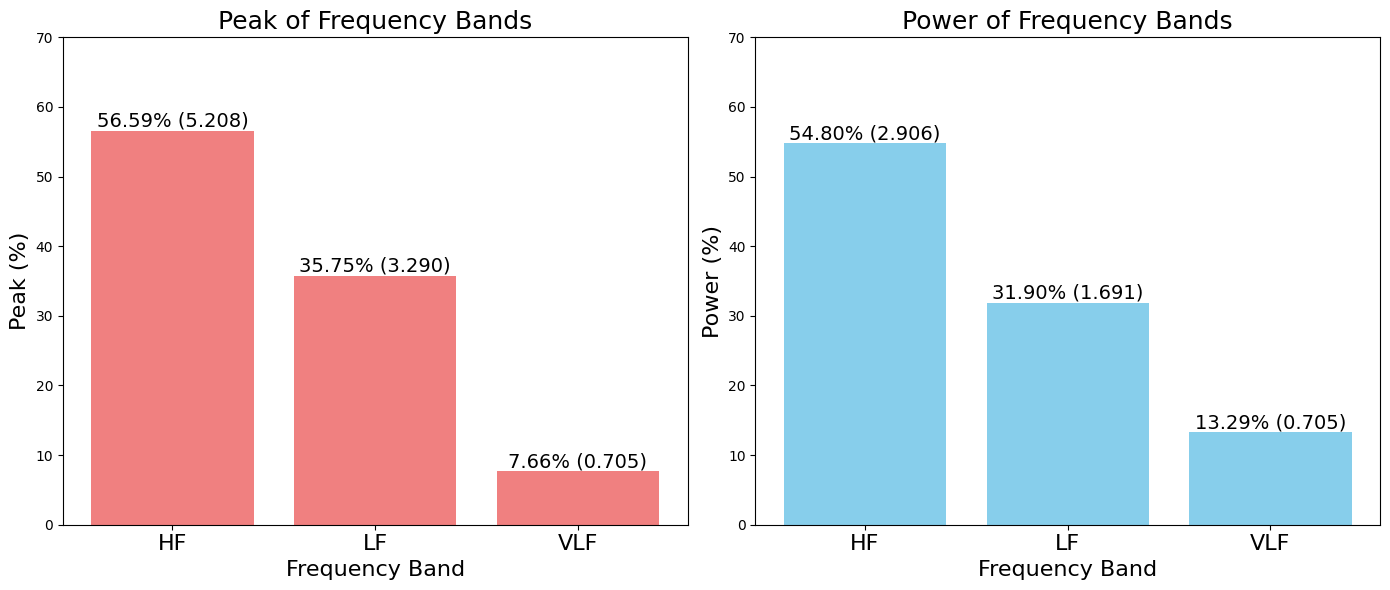

In [18]:
# 1. VLF, LF, HF의 power, peak 데이터 준비
bands = ['HF', 'LF', 'VLF']
peak_values = [file1_FFT_HRV_analysis[f'{band}_peak'] for band in bands]
power_values = [file1_FFT_HRV_analysis[f'{band}_power'] for band in bands]

# 2. Peak 값과 Power 값의 합 계산
peak_sum = sum(peak_values)
power_sum = sum(power_values)

# 3. 각각의 값을 0~1 사이로 정규화 (비율 유지)
normalized_peak_values = [val / peak_sum for val in peak_values]
normalized_power_values = [val / power_sum for val in power_values]

# 4. 정규화된 값을 0~100 사이로 변환 (퍼센티지로 표현)
percentage_peak_values = [val * 100 for val in normalized_peak_values]
percentage_power_values = [val * 100 for val in normalized_power_values]

# 5. 그래프를 두 개로 나누어 표시
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Peak 그래프
bars_peak = ax1.bar(bands, percentage_peak_values, color='lightcoral')
ax1.set_title('Peak of Frequency Bands', fontsize=18)  # 제목 글씨 크기 키우기
ax1.set_xlabel('Frequency Band', fontsize=16)  # x축 글씨 크기 키우기
ax1.set_ylabel('Peak (%)', fontsize=16)  # y축 글씨 크기 키우기
ax1.set_ylim(0, 70)  # y축 범위 0~70으로 설정

# 각 막대 위에 값 표시 (퍼센티지와 원래 값)
for i, bar in enumerate(bars_peak):
    yval = bar.get_height()
    # '퍼센티지 (값)' 형식으로 수정, 글씨 크기도 키우기
    ax1.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}% ({peak_values[i]:.3f})', 
             ha='center', va='bottom', fontsize=14)

# Power 그래프
bars_power = ax2.bar(bands, percentage_power_values, color='skyblue')
ax2.set_title('Power of Frequency Bands', fontsize=18)  # 제목 글씨 크기 키우기
ax2.set_xlabel('Frequency Band', fontsize=16)  # x축 글씨 크기 키우기
ax2.set_ylabel('Power (%)', fontsize=16)  # y축 글씨 크기 키우기
ax2.set_ylim(0, 70)  # y축 범위 0~70으로 설정

# 각 막대 위에 값 표시 (퍼센티지와 원래 값)
for i, bar in enumerate(bars_power):
    yval = bar.get_height()
    # '퍼센티지 (값)' 형식으로 수정, 글씨 크기도 키우기
    ax2.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}% ({power_values[i]:.3f})', 
             ha='center', va='bottom', fontsize=14)

# x축 레이블의 글씨 크기 키우기
ax1.set_xticklabels(bands, fontsize=16)  # x축 레이블 글씨 크기 키우기
ax2.set_xticklabels(bands, fontsize=16)  # x축 레이블 글씨 크기 키우기

# 그래프 간격 조정
plt.tight_layout()
plt.show()
